In [1]:
!pip install tensorflow matplotlib


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Load EMNIST digits
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/digits',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Check dataset info
print(ds_info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/digits/incomplete.JK8LOU_3.1.0/emnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/digits/incomplete.JK8LOU_3.1.0/emnist-test.tfrecord*...:   0%|     …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/digits/3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/digits/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Digits
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/root/tensorflow_datasets/emnist/digits/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=120.32 MiB,
    features=FeaturesDict({
        'image': Image(sh

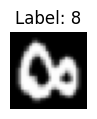

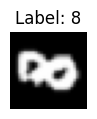

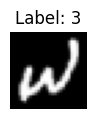

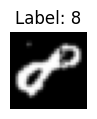

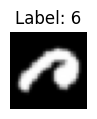

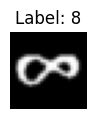

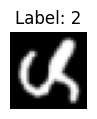

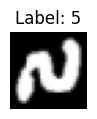

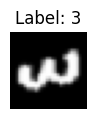

In [4]:
import matplotlib.pyplot as plt

for image, label in ds_train.take(9):
    plt.figure(figsize=(1,1))
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")
    plt.show()

In [5]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

batch_size = 128

ds_train = ds_train.map(preprocess).cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)


In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 digits
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(ds_train, epochs=5, validation_data=ds_test)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 214s 113ms/step - accuracy: 0.9440 - loss: 0.1912 - val_accuracy: 0.9915 - val_loss: 0.0297
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 170s 91ms/step - accuracy: 0.9913 - loss: 0.0294 - val_accuracy: 0.9936 - val_loss: 0.0224
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 172s 92ms/step - accuracy: 0.9941 - loss: 0.0202 - val_accuracy: 0.9937 - val_loss: 0.0210
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 174s 93ms/step - accuracy: 0.9957 - loss: 0.0150 - val_accuracy: 0.9941 - val_loss: 0.0197
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 170s 91ms/step - accuracy: 0.9968 - loss: 0.0109 - val_accuracy: 0.9951 - val_loss: 0.0182


In [8]:
test_loss, test_accuracy = model.evaluate(ds_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9951 - loss: 0.0176
Test Accuracy: 99.51%


In [9]:
model.save("emnist_digit_model.h5")


MAKE PREDICTIONS:

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in ds_test:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, digits=4)
print(report)

with open("classification_report_emnist.txt", "w") as f:
    f.write(report)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━

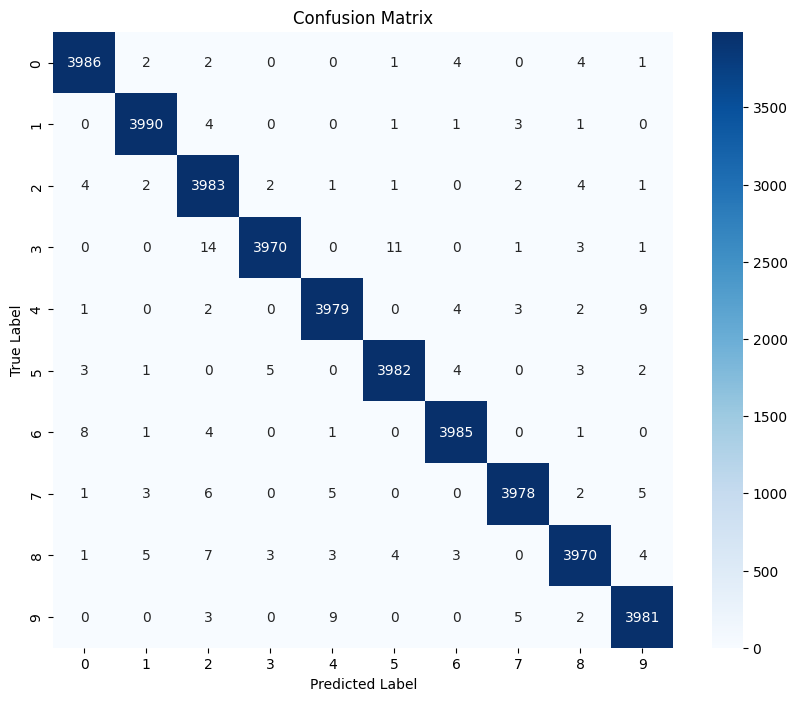

In [12]:
#Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("confusion_matrix_emnist.png")
plt.show()

EXMAPLE

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


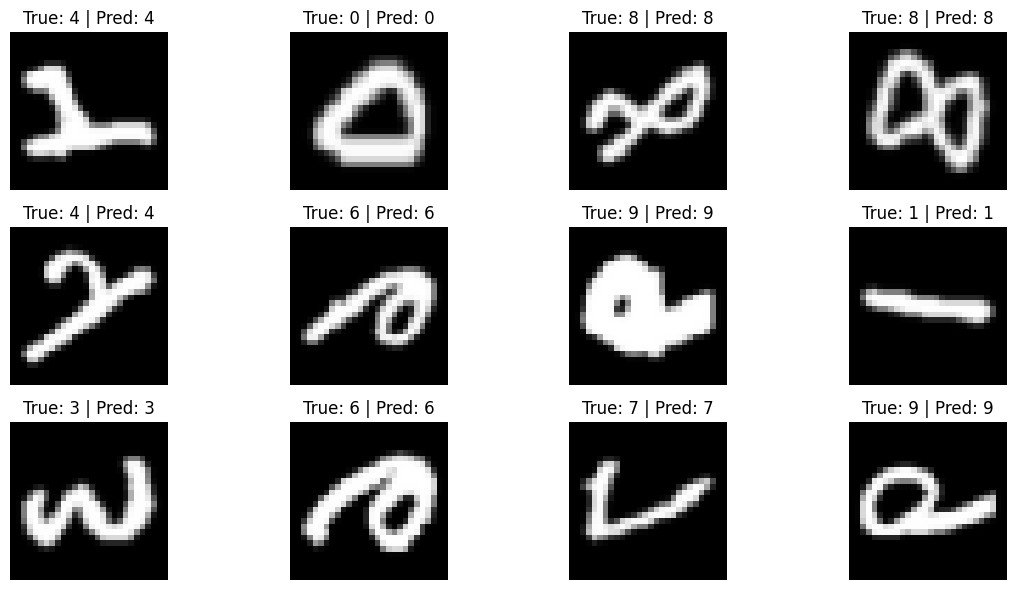

In [13]:
import random

for images, labels in ds_test.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(12):
        idx = random.randint(0, len(images) - 1)
        plt.subplot(3, 4, i+1)
        plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
        plt.title(f"True: {labels[idx].numpy()} | Pred: {pred_labels[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("sample_predictions_emnist.png")
    plt.show()


In [14]:
# Save full model
model.save("emnist_digit_model.h5")